# Mechanistic Interpretability Shark Tank: A Tiny Full Adder

We will train a tiny MLP, inspect its hidden neurons, and investigate whether one neuron **helps the model predict a carry**.

This is based on the starter: data → one hidden ReLU layer → activations → single-neuron ablation → ablation sweep.

**Run all cells from the top.** Requires PyTorch and Matplotlib (both are available in Colab).


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from itertools import product

# Uses a fixed seed to make the experiment reproducible in the same environment.
torch.manual_seed(0)

### Data Generation

A **one-bit full adder** adds `a + b + carry_in`. The result is represented by two bits: `sum_bit` is the low bit, and `carry_out` is the high bit.

For example, `1 + 1 + 0 = 2`, which is `10` in binary: sum bit `0`, carry out `1`.

| Number of input 1s | Sum bit (odd parity) | Carry out (at least two 1s) |
|---|---|---|
| 0 | 0 | 0 |
| 1 | 1 | 0 |
| 2 | 0 | 1 |
| 3 | 1 | 1 |

There are only **eight possible inputs**, so we use all of them for training and inspection. Accuracy here measures learning this truth table

In [8]:
# setup and display training dataset

X = torch.tensor(list(product([0, 1], repeat=3)), dtype=torch.float32)
counts = X.sum(dim=1)
y = torch.stack([counts % 2, (counts >= 2).float()], dim=1)
output_names = ["sum_bit", "carry_out"]  # Column order throughout the notebook.
input_labels = ["".join(str(int(bit)) for bit in row) for row in X]

print("a b carry_in -> sum_bit carry_out")
for row, target in zip(X.int().tolist(), y.int().tolist()):
    print(f"{row} -> {target}")

a b carry_in -> sum_bit carry_out
[0, 0, 0] -> [0, 0]
[0, 0, 1] -> [1, 0]
[0, 1, 0] -> [1, 0]
[0, 1, 1] -> [0, 1]
[1, 0, 0] -> [1, 0]
[1, 0, 1] -> [0, 1]
[1, 1, 0] -> [0, 1]
[1, 1, 1] -> [1, 1]


### Build and Train a Tiny MLP

The architecture is **3 inputs → 8 ReLU neurons → 2 outputs**. Follows the starter with the same 2 layers `fc1`, `fc2` and returned hidden activations.

A **logit** is an output score before conversion to probability. `sigmoid(logit)` gives a probability for each bit;
a nonnegative logit predicts `1`. We use `BCEWithLogitsLoss` because both targets are binary. 
The two outputs are separate bits, so both may be `1` at once (per truth table)

In [9]:
# setup simple MLP for full adder with 3 input units, 8 hidden units, and 2 output units

class FullAdderMLP(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=8):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = self.fc2(h)
        return out, h  # Return activations for interpretability.

model = FullAdderMLP()
print(model)

# use simple Adam optimizer and BCEWithLogitsLoss for training
optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
criterion = nn.BCEWithLogitsLoss()
losses = []

# training loop with more than enough epochs
for epoch in range(2000):
    model.train()
    logits, _ = model(X)
    loss = criterion(logits, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

model.eval()

# evaluate the trained model on the training dataset
with torch.no_grad():
    baseline_logits, hidden_all = model(X)
    baseline_probs = torch.sigmoid(baseline_logits)
    baseline_preds = (baseline_logits >= 0).int()
    baseline_correct = (baseline_preds == y.int()).sum(dim=0)

print(f"Final training loss: {losses[-1]:.5f}")
for k, name in enumerate(output_names):
    print(f"{name}: {baseline_correct[k].item()}/8 correct")
print("Both bits correct:", (baseline_preds == y.int()).all(dim=1).sum().item(), "/8")
print("\nInput | True [sum, carry] | Predicted [sum, carry]")
for label, target, pred in zip(input_labels, y.int().tolist(), baseline_preds.tolist()):
    print(f"{label}   | {target}           | {pred}")


FullAdderMLP(
  (fc1): Linear(in_features=3, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=2, bias=True)
)
Final training loss: 0.00027
sum_bit: 8/8 correct
carry_out: 8/8 correct
Both bits correct: 8 /8

Input | True [sum, carry] | Predicted [sum, carry]
000   | [0, 0]           | [0, 0]
001   | [1, 0]           | [1, 0]
010   | [1, 0]           | [1, 0]
011   | [0, 1]           | [0, 1]
100   | [1, 0]           | [1, 0]
101   | [0, 1]           | [0, 1]
110   | [0, 1]           | [0, 1]
111   | [1, 1]           | [1, 1]


### Print Activations of a Sample Input

For `110`, the correct answer is `[0, 1]`. 

Hidden activations are the values **after ReLU**, which clips negative values to zero. 

An active neuron need not be a detector for the correct answer: we still need to inspect other inputs and its effect on the outputs.

In [10]:
# simple input with deterministic output and inspect the model's internal activations

sample_input = torch.tensor([[1, 1, 0]], dtype=torch.float32)
with torch.no_grad():
    sample_logits, sample_hidden = model(sample_input)

print("Input [a, b, carry_in]:", sample_input.int().tolist())
print("Hidden activations:", sample_hidden)
print("Output logits [sum, carry]:", sample_logits)
print("Output probabilities:", torch.sigmoid(sample_logits))
print("Predicted bits:", (sample_logits >= 0).int().tolist())

Input [a, b, carry_in]: [[1, 1, 0]]
Hidden activations: tensor([[2.2709, 0.0000, 1.3241, 0.0000, 0.0000, 0.0000, 0.0000, 1.5374]])
Output logits [sum, carry]: tensor([[-8.7482, 10.4768]])
Output probabilities: tensor([[1.5873e-04, 9.9997e-01]])
Predicted bits: [[0, 1]]


### Plot Hidden Activations by Count and by Exact Input

The left heatmap follows the starter: average activations for each number of 1s. The right heatmap shows **every input**, ordered by count, so an average cannot hide differences between bit arrangements. Neuron indices start at `0`.

Look for neurons that activate more on carry cases (counts `2` and `3`). Then check whether they also activate on any no-carry case. This is **observational evidence**: it identifies a pattern, but does not show whether the model uses the neuron to predict carry.

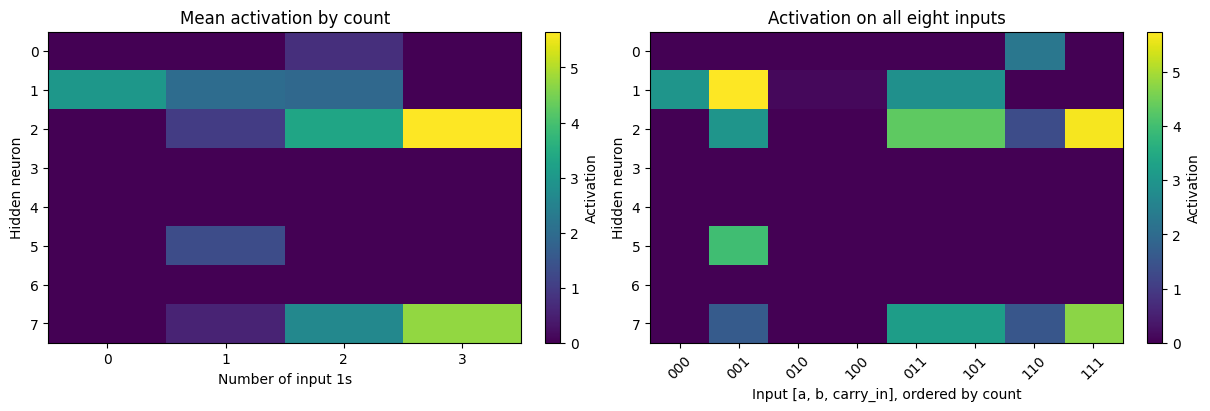

In [11]:
hidden_dim = model.fc1.out_features
avg_activations = torch.stack([
    hidden_all[counts == c].mean(dim=0) for c in range(4)
])
order = counts.argsort()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
image = axes[0].imshow(avg_activations.T.numpy(), aspect="auto", cmap="viridis")
axes[0].set_xticks(range(4))
axes[0].set_xlabel("Number of input 1s")
axes[0].set_ylabel("Hidden neuron")
axes[0].set_yticks(range(hidden_dim))
axes[0].set_title("Mean activation by count")
fig.colorbar(image, ax=axes[0], label="Activation")

image = axes[1].imshow(hidden_all[order].T.numpy(), aspect="auto", cmap="viridis")
axes[1].set_xticks(range(8), [input_labels[i] for i in order.tolist()], rotation=45)
axes[1].set_xlabel("Input [a, b, carry_in], ordered by count")
axes[1].set_ylabel("Hidden neuron")
axes[1].set_yticks(range(hidden_dim))
axes[1].set_title("Activation on all eight inputs")
fig.colorbar(image, ax=axes[1], label="Activation")
plt.show()

Looking at Neuron 2's rows, it seems pretty active with carrys scenarios.

### Neuron Ablation (Single Neuron)

Deeper dive into what makes carry work with simple exploratory rule (but not causal without intervention) 

Thus, choose a candidate with the largest **mean activation on carry cases minus mean activation on no-carry cases**. 

An **ablation** sets the chosen activation to zero, leaving the trained weights and other neurons unchanged. We first try the starter's single-input experiment on `110`.

For this linear output layer, each neuron contributes `output_weight × activation` to each logit. Removing it changes that logit by the negative of its contribution. A positive output weight supports that output bit; a negative one opposes it.

In [12]:
carry_cases = y[:, 1] == 1
activation_gap = (hidden_all[carry_cases].mean(dim=0)
                  - hidden_all[~carry_cases].mean(dim=0))
neuron_to_zero = activation_gap.argmax().item()  # Or set an index to inspect another neuron.

# force neuron to zero
with torch.no_grad():
    original_logits, h = model(sample_input)
    h[:, neuron_to_zero] = 0
    modified_logits = model.fc2(h)

print("Selected neuron:", neuron_to_zero)
print(f"Carry/no-carry mean activation gap: {activation_gap[neuron_to_zero]:.3f}")
print("Its output weights [sum, carry]:", model.fc2.weight[:, neuron_to_zero].detach())
print("\nInput: 110; true bits: [0, 1]")
print("Original probabilities:", torch.sigmoid(original_logits))
print("Ablated probabilities: ", torch.sigmoid(modified_logits))
print("Logit change (ablated - original):", modified_logits - original_logits)

Selected neuron: 2
Carry/no-carry mean activation gap: 3.156
Its output weights [sum, carry]: tensor([0.6068, 3.6709])

Input: 110; true bits: [0, 1]
Original probabilities: tensor([[1.5873e-04, 9.9997e-01]])
Ablated probabilities:  tensor([[7.1077e-05, 9.9637e-01]])
Logit change (ablated - original): tensor([[-0.8035, -4.8607]])


### What Does the Single-Input Ablation Tell Us?

A negative carry-logit change means the neuron supplied positive evidence for carry on **this input**. It does not establish its role on the other seven inputs.

Probabilities can stay close to `0` or `1` even when logits change substantially. A neuron can affect the score without changing the predicted bit. We therefore inspect both logit changes and classification errors next.

### Neuron Ablation (Sweep of Neurons)

Following the starter, we zero one neuron at a time and record **ablated minus original** output scores. Here we test all eight inputs and both outputs.

The bars summarize effects separately for carry and no-carry cases. Negative bars mean removing the neuron lowered that output's logit. Compare the carry panel with the sum panel: does a neuron support both outputs, oppose one of them, or mainly affect carry?

A zero effect does not by itself show redundancy: a neuron might simply be inactive. A nonzero score change without an accuracy drop means the remaining score still crosses the correct decision threshold.

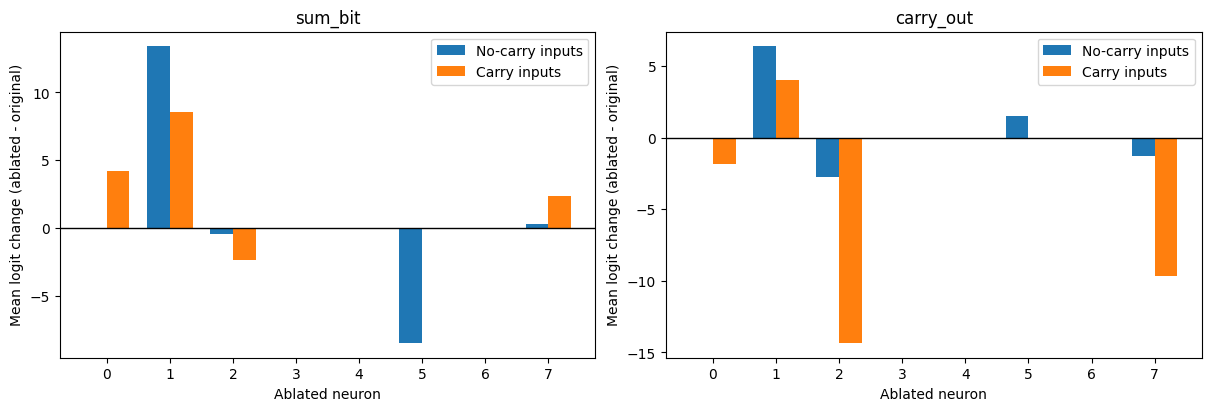

Neuron | Sum correct | Carry correct (out of 8)
     0 |           7 |             8
     1 |           5 |             7
     2 |           8 |             6
     3 |           8 |             8
     4 |           8 |             8
     5 |           7 |             8
     6 |           8 |             8
     7 |           8 |             8


In [13]:
ablation_deltas = torch.zeros((hidden_dim, len(X), 2))
ablation_correct = torch.zeros((hidden_dim, 2), dtype=torch.int64)

with torch.no_grad():
    for i in range(hidden_dim):
        h = hidden_all.clone()  # Preserve the original activations.
        h[:, i] = 0
        ablated_logits = model.fc2(h)
        ablation_deltas[i] = ablated_logits - baseline_logits
        ablation_correct[i] = ((ablated_logits >= 0) == y.bool()).sum(dim=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
indices = torch.arange(hidden_dim).numpy()
for k, ax in enumerate(axes):
    ax.bar(indices - 0.18, ablation_deltas[:, ~carry_cases, k].mean(dim=1).numpy(),
           width=0.36, label="No-carry inputs")
    ax.bar(indices + 0.18, ablation_deltas[:, carry_cases, k].mean(dim=1).numpy(),
           width=0.36, label="Carry inputs")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(indices)
    ax.set_xlabel("Ablated neuron")
    ax.set_ylabel("Mean logit change (ablated - original)")
    ax.set_title(output_names[k])
    ax.legend()
plt.show()

print("Neuron | Sum correct | Carry correct (out of 8)")
for i in range(hidden_dim):
    print(f"{i:6d} | {ablation_correct[i, 0].item():11d} | {ablation_correct[i, 1].item():13d}")

### Evidence for Our Selected Neuron on Every Input

Return to the selected neuron and inspect individual cases. The table includes its activation, carry probabilities before and after ablation, and changes in both logits.

Use it to check two things:

- **Counterexamples:** Does it activate when the correct carry is `0`? If so, calling it a pure carry detector would be too strong.
- **Uneven effects:** Are all carry inputs affected equally? Compare different arrangements with two 1s, and compare `001` with `011` (flipping `b`). The input's carry label changes, but does this neuron's activation cleanly distinguish them?

In [14]:
with torch.no_grad():
    h = hidden_all.clone()
    h[:, neuron_to_zero] = 0
    selected_logits = model.fc2(h)
    selected_probs = torch.sigmoid(selected_logits)

print(f"Neuron {neuron_to_zero}: all eight inputs")
print("Input | True carry | Activation | P(carry) before -> after | Delta sum | Delta carry")
for r, label in enumerate(input_labels):
    delta = ablation_deltas[neuron_to_zero, r]
    print(f"{label}   | {int(y[r, 1]):10d} | {hidden_all[r, neuron_to_zero]:10.3f} | "
          f"{baseline_probs[r, 1]:.4f} -> {selected_probs[r, 1]:.4f}          | "
          f"{delta[0]:9.3f} | {delta[1]:11.3f}")

print("\nMean activation:")
print(f"  Carry cases:    {hidden_all[carry_cases, neuron_to_zero].mean():.3f}")
print(f"  No-carry cases: {hidden_all[~carry_cases, neuron_to_zero].mean():.3f}")
for k, name in enumerate(output_names):
    print(f"{name} correct: {baseline_correct[k].item()}/8 before -> "
          f"{ablation_correct[neuron_to_zero, k].item()}/8 after ablation")

Neuron 2: all eight inputs
Input | True carry | Activation | P(carry) before -> after | Delta sum | Delta carry
000   |          0 |      0.000 | 0.0000 -> 0.0000          |     0.000 |       0.000
001   |          0 |      2.996 | 0.0000 -> 0.0000          |    -1.818 |     -10.998
010   |          0 |      0.000 | 0.0011 -> 0.0011          |     0.000 |       0.000
011   |          1 |      4.323 | 1.0000 -> 0.0080          |    -2.623 |     -15.868
100   |          0 |      0.000 | 0.0011 -> 0.0011          |     0.000 |       0.000
101   |          1 |      4.323 | 1.0000 -> 0.0080          |    -2.624 |     -15.871
110   |          1 |      1.324 | 1.0000 -> 0.9964          |    -0.804 |      -4.861
111   |          1 |      5.650 | 1.0000 -> 0.9997          |    -3.428 |     -20.740

Mean activation:
  Carry cases:    3.905
  No-carry cases: 0.749
sum_bit correct: 8/8 before -> 8/8 after ablation
carry_out correct: 8/8 before -> 6/8 after ablation


### Shark Tank Claim (based on evidence)

For the default run (`seed = 0`), the selected neuron is **neuron 2**. 

The trained model gets both bits correct on all eight inputs. Ablating neuron 2 changes carry accuracy from **8/8 to 6/8**, while sum accuracy stays **8/8**.

A defensible pitch for those results is:

> **Claim:** Neuron 2 supplies positive evidence for carry, with a larger effect on carry logits than on sum logits. Removing it causes carry errors on `011` and `101`, while all sum-bit decisions remain correct.
>
> **Evidence:** It is more active on carry inputs on average, and we intervened on the neuron rather than only observing it. The table above shows which decisions actually change.
>
> **Limitation:** It also activates on `001`, which has no carry, and its effects differ across carry inputs. It is not a pure carry detector (may have superposition), and it also affects sum logits even though those decisions remain correct.

This supports a claim about **a neuron's contribution in this trained model**, rather than a claim that it alone implements carry. Zeroing an activation (Feature Clamping) is an artificial intervention; other neurons and the output bias also contribute. This examined one training run on a finite truth table, and did not demonstrate a universal mechanism.